# UC3 — Segmentación de targets de upselling Hey Pro

**Autor:** Jorge Velázquez (`jv`)
**Proyecto:** datamoles — Havi
**Tipo:** Pipeline de segmentación + cálculo de ROI (no ML supervisado)
**Filosofía:** calidad sobre cantidad — solo activar usuarios con propensión y valor económico real.

## Objetivo

Cruzar `cashback_perdido_mes` × `score_propension` para crear una matriz 2x2 de prioridad
y enriquecerla con señales de timing (`dias_desde_ultimo_login`) y de fricción (`nomina_domiciliada`).

## Segmentos
- **A**: alto cashback + alta propensión → mensaje inmediato
- **B**: alto cashback + baja propensión → necesita más nurturing
- **C**: bajo cashback → no interrumpir


---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

ROOT = Path('..').resolve().parent
FEAT_DIR = ROOT / 'outputs' / 'features'
DATA_DIR = ROOT / 'Datathon_Hey_2026_dataset_transacciones 1' / 'dataset_transacciones'
OUT_UC3  = ROOT / 'outputs' / 'uc3'
FIG_DIR  = ROOT / 'notebooks' / 'uc3'
OUT_UC3.mkdir(parents=True, exist_ok=True)

# Parámetros del ticket
UMBRAL_CASHBACK_ALTO = 300.0     # $/mes
UMBRAL_CASHBACK_MEDIO = 100.0    # $/mes
UMBRAL_PROPENSION_ALTA = 70.0
UMBRAL_DIAS_LOGIN_ALTA = 1
UMBRAL_DIAS_LOGIN_MEDIA = 7

# Supuestos del ROI (placeholders — validar con product owner)
REVENUE_MENSUAL_HEY_PRO_MXN = 99.0
TASA_CONVERSION_ESTIMADA = 0.20


## 1. Carga y filtrado a candidatos `hey_pro`

In [2]:
df_cand = pd.read_parquet(FEAT_DIR / 'feat_uc3_candidates.parquet')
df_cli  = pd.read_csv(DATA_DIR / 'hey_clientes.csv',
                       usecols=['user_id','es_hey_pro','nomina_domiciliada','dias_desde_ultimo_login'],
                       low_memory=False)
print('Candidatos:', df_cand.shape, '| Clientes:', df_cli.shape)

df_hp = df_cand[df_cand['producto_candidato']=='hey_pro'].copy()
# La tabla de candidatos ya trae nomina_domiciliada; preferimos la fuente cliente (es la verdad oficial).
df_hp = df_hp.drop(columns=[c for c in ['nomina_domiciliada'] if c in df_hp.columns])
df_hp = df_hp.merge(df_cli, on='user_id', how='left')
df_hp = df_hp[df_hp['es_hey_pro']==False].copy()  # excluir los que ya son Pro
print('Candidatos hey_pro (no-Pro):', df_hp.shape)
df_hp.head(3)


Candidatos: (78563, 8) | Clientes: (15025, 4)
Candidatos hey_pro (no-Pro): (7680, 10)


,user_id,producto_candidato,score_propension,cashback_perdido_mes,ingreso_mensual_mxn,score_buro,menciona_producto,es_hey_pro,nomina_domiciliada,dias_desde_ultimo_login
0,USR-00004,hey_pro,52.73,23.38,61000,837,0,False,False,16
1,USR-00009,hey_pro,60.00,0.00,19500,665,0,False,True,7
2,USR-00010,hey_pro,52.93,25.09,23500,609,0,False,False,2


## 2. Diagnóstico de las distribuciones (validar umbrales del ticket)

In [3]:
print('--- cashback_perdido_mes ---')
print(df_hp['cashback_perdido_mes'].describe(percentiles=[.5,.75,.9,.95,.99]).to_string())
print('\n--- score_propension ---')
print(df_hp['score_propension'].describe(percentiles=[.5,.75,.9,.95,.99]).to_string())
print('\n--- dias_desde_ultimo_login ---')
print(df_hp['dias_desde_ultimo_login'].describe().to_string())

# Cobertura de los umbrales del ticket
n_total = len(df_hp)
n_cb_high = (df_hp['cashback_perdido_mes'] > UMBRAL_CASHBACK_ALTO).sum()
n_prop_high = (df_hp['score_propension'] > UMBRAL_PROPENSION_ALTA).sum()
print(f'\nCobertura umbrales del ticket:')
print(f'  cashback > ${UMBRAL_CASHBACK_ALTO:.0f}/mes : {n_cb_high:,} / {n_total:,}  ({n_cb_high/n_total:.1%})')
print(f'  score_propension > {UMBRAL_PROPENSION_ALTA:.0f}     : {n_prop_high:,} / {n_total:,}  ({n_prop_high/n_total:.1%})')


--- cashback_perdido_mes ---
count    7680.000000
mean       25.461203
std        63.453190
min         0.000000
50%         7.395000
75%        21.650000
90%        56.116000
95%       129.234500
99%       307.256600
max      1291.060000

--- score_propension ---
count    7680.000000
mean       57.025478
std         7.254063
min        50.000000
50%        55.000000
75%        61.530000
90%        65.080000
95%        68.281000
99%        85.000000
max        90.000000

--- dias_desde_ultimo_login ---
count    7680.000000
mean       29.338932
std        44.144592
min         0.000000
25%         4.000000
50%        11.000000
75%        20.000000
max       180.000000

Cobertura umbrales del ticket:
  cashback > $300/mes : 82 / 7,680  (1.1%)
  score_propension > 70     : 303 / 7,680  (3.9%)


## 3. Matriz 2x2 de segmentación + asignación A/B/C

In [4]:
def asignar_segmento(row):
    cb = row['cashback_perdido_mes']
    sp = row['score_propension']
    if cb > UMBRAL_CASHBACK_ALTO and sp > UMBRAL_PROPENSION_ALTA:
        return 'A'  # alto cashback + alta propensión → mensaje inmediato
    if cb > UMBRAL_CASHBACK_MEDIO and sp <= UMBRAL_PROPENSION_ALTA:
        return 'B'  # alto cashback + baja propensión → necesita nurturing
    return 'C'      # resto → no interrumpir

df_hp['segmento_uc3'] = df_hp.apply(asignar_segmento, axis=1)
print('Distribución por segmento:')
print(df_hp['segmento_uc3'].value_counts().to_string())
print(f'\nTotal usuarios analizados: {len(df_hp):,}')


Distribución por segmento:
segmento_uc3
C    7393
B     205
A      82

Total usuarios analizados: 7,680


## 4. Análisis del segmento A — fricción y timing

In [5]:
seg_a = df_hp[df_hp['segmento_uc3']=='A']
n_a = len(seg_a)
n_a_nomina = int(seg_a['nomina_domiciliada'].sum())
pct_a_nomina = n_a_nomina / n_a if n_a else 0

print(f'Segmento A — análisis fricción:')
print(f'  Total                          : {n_a:,}')
print(f'  Con nomina_domiciliada=True    : {n_a_nomina:,}  ({pct_a_nomina:.1%})  ← activación zero-friction')
print(f'  Sin nómina (paso adicional)    : {n_a - n_a_nomina:,}')

# Timing: usuarios A activos en últimas 24h
n_a_login_ayer = int((seg_a['dias_desde_ultimo_login'] <= UMBRAL_DIAS_LOGIN_ALTA).sum())
n_a_login_semana = int((seg_a['dias_desde_ultimo_login'] <= UMBRAL_DIAS_LOGIN_MEDIA).sum())
print(f'\nSegmento A — timing:')
print(f'  Login en último día            : {n_a_login_ayer:,}  ({n_a_login_ayer/n_a:.1%} si n>0)')
print(f'  Login en última semana         : {n_a_login_semana:,}  ({n_a_login_semana/n_a:.1%} si n>0)')

# Subset perfecto: A + nómina + login fresh
n_perfecto = int(((seg_a['nomina_domiciliada']==True) &
                  (seg_a['dias_desde_ultimo_login'] <= UMBRAL_DIAS_LOGIN_ALTA)).sum())
print(f'\n  Subset PREMIUM (A + nómina + login ayer): {n_perfecto:,}')


Segmento A — análisis fricción:
  Total                          : 82
  Con nomina_domiciliada=True    : 0  (0.0%)  ← activación zero-friction
  Sin nómina (paso adicional)    : 82

Segmento A — timing:
  Login en último día            : 9  (11.0% si n>0)
  Login en última semana         : 36  (43.9% si n>0)

  Subset PREMIUM (A + nómina + login ayer): 0


## 5. Cálculo de ROI estimado para el banco

*Supuestos*: revenue mensual de Hey Pro = $99 MXN (placeholder), conversión esperada del segmento A = 20%.

In [6]:
def calcular_roi(n_usuarios, conversion=TASA_CONVERSION_ESTIMADA, revenue=REVENUE_MENSUAL_HEY_PRO_MXN):
    n_convertidos = int(n_usuarios * conversion)
    revenue_mensual = n_convertidos * revenue
    revenue_anual = revenue_mensual * 12
    return {'n_convertidos': n_convertidos,
            'revenue_mensual_mxn': round(revenue_mensual, 2),
            'revenue_anual_mxn': round(revenue_anual, 2)}

# Escenarios
roi_a_total = calcular_roi(n_a)
roi_a_premium = calcular_roi(n_perfecto)
print(f'ROI escenario 1 — todo el segmento A ({n_a:,} usuarios, conv=20%):')
print(f'  Conversiones esperadas    : {roi_a_total["n_convertidos"]:,}')
print(f'  Revenue mensual           : ${roi_a_total["revenue_mensual_mxn"]:,.0f}')
print(f'  Revenue anual estimado    : ${roi_a_total["revenue_anual_mxn"]:,.0f}')
print(f'\nROI escenario 2 — subset PREMIUM ({n_perfecto:,} usuarios, conv=20%):')
print(f'  Revenue anual estimado    : ${roi_a_premium["revenue_anual_mxn"]:,.0f}')

# Sensibilidad al supuesto de revenue
print(f'\nSensibilidad — ROI anual del segmento A según revenue mensual:')
for r in [49, 99, 149]:
    s = calcular_roi(n_a, revenue=r)
    print(f'  ${r}/mes : ${s["revenue_anual_mxn"]:,.0f}')


ROI escenario 1 — todo el segmento A (82 usuarios, conv=20%):
  Conversiones esperadas    : 16
  Revenue mensual           : $1,584
  Revenue anual estimado    : $19,008

ROI escenario 2 — subset PREMIUM (0 usuarios, conv=20%):
  Revenue anual estimado    : $0

Sensibilidad — ROI anual del segmento A según revenue mensual:
  $49/mes : $9,408
  $99/mes : $19,008
  $149/mes : $28,608


## 6. Regla de timing — `prioridad_envio`

In [7]:
def asignar_prioridad(row):
    if row['segmento_uc3'] == 'A' and row['dias_desde_ultimo_login'] <= UMBRAL_DIAS_LOGIN_ALTA:
        return 'alta'
    if row['segmento_uc3'] == 'A' and row['dias_desde_ultimo_login'] <= UMBRAL_DIAS_LOGIN_MEDIA:
        return 'media'
    if row['segmento_uc3'] == 'B':
        return 'media'  # nurturing programado
    return 'baja'

df_hp['prioridad_envio'] = df_hp.apply(asignar_prioridad, axis=1)
df_hp['ready_to_activate_zero_friction'] = (
    (df_hp['segmento_uc3']=='A')
    & (df_hp['nomina_domiciliada']==True)
    & (df_hp['dias_desde_ultimo_login'] <= UMBRAL_DIAS_LOGIN_ALTA)
)

print('Distribución por prioridad_envio:')
print(df_hp['prioridad_envio'].value_counts().to_string())
print(f'\nReady to activate (zero-friction): {df_hp["ready_to_activate_zero_friction"].sum():,}')


Distribución por prioridad_envio:
prioridad_envio
baja     7439
media     232
alta        9

Ready to activate (zero-friction): 0


## 7. Visualización de la matriz 2x2

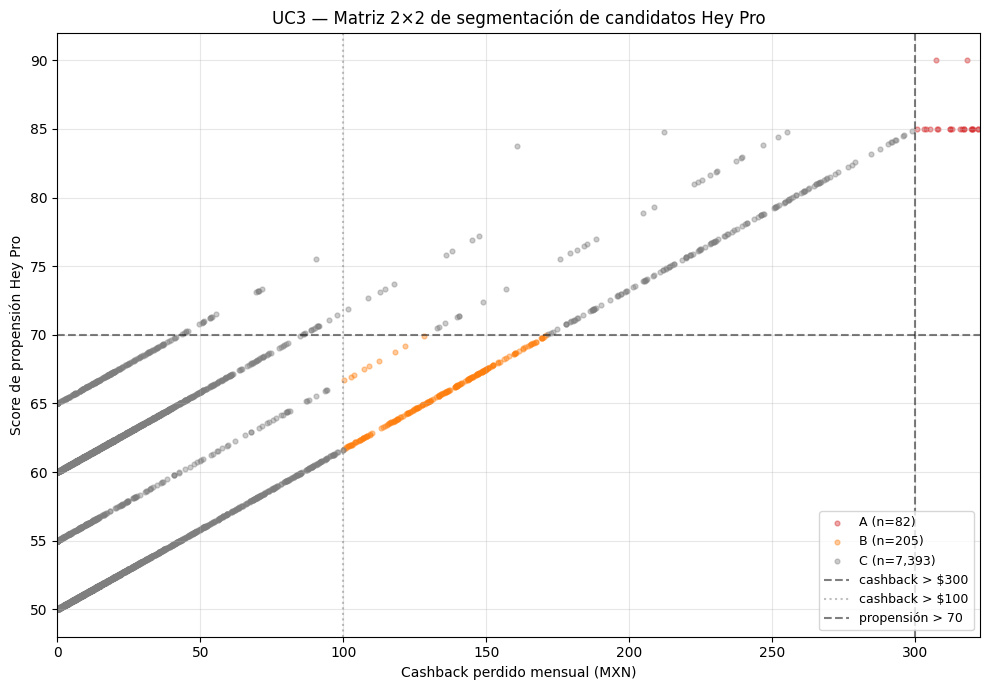

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = {'A': 'tab:red', 'B': 'tab:orange', 'C': 'tab:gray'}
for seg, color in colors.items():
    sub = df_hp[df_hp['segmento_uc3']==seg]
    ax.scatter(sub['cashback_perdido_mes'], sub['score_propension'],
               s=12, alpha=0.4, color=color, label=f'{seg} (n={len(sub):,})')

ax.axvline(UMBRAL_CASHBACK_ALTO, color='black', linestyle='--', alpha=0.5,
           label=f'cashback > ${UMBRAL_CASHBACK_ALTO:.0f}')
ax.axvline(UMBRAL_CASHBACK_MEDIO, color='gray', linestyle=':', alpha=0.5,
           label=f'cashback > ${UMBRAL_CASHBACK_MEDIO:.0f}')
ax.axhline(UMBRAL_PROPENSION_ALTA, color='black', linestyle='--', alpha=0.5,
           label=f'propensión > {UMBRAL_PROPENSION_ALTA:.0f}')

ax.set_xlim(0, max(50, df_hp['cashback_perdido_mes'].quantile(0.99) * 1.05))
ax.set_xlabel('Cashback perdido mensual (MXN)')
ax.set_ylabel('Score de propensión Hey Pro')
ax.set_title('UC3 — Matriz 2×2 de segmentación de candidatos Hey Pro')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'uc3_fig_segmentacion_2x2.png', dpi=120, bbox_inches='tight')
plt.show()


## 8. Persistir tabla final + métricas

In [9]:
final_cols = ['user_id','cashback_perdido_mes','score_propension',
              'nomina_domiciliada','dias_desde_ultimo_login',
              'segmento_uc3','ready_to_activate_zero_friction','prioridad_envio',
              'menciona_producto','ingreso_mensual_mxn','score_buro']
df_final = df_hp[final_cols].sort_values(
    ['segmento_uc3','prioridad_envio','cashback_perdido_mes'],
    ascending=[True, True, False]
).reset_index(drop=True)

df_final.to_parquet(OUT_UC3 / 'uc3_segmentacion_final.parquet', index=False)
print('Wrote', OUT_UC3 / 'uc3_segmentacion_final.parquet  shape =', df_final.shape)

metrics = {
    'fecha_evaluacion': pd.Timestamp.utcnow().isoformat(),
    'n_candidatos_total': int(len(df_hp)),
    'segmentos': {
        'A': int((df_hp['segmento_uc3']=='A').sum()),
        'B': int((df_hp['segmento_uc3']=='B').sum()),
        'C': int((df_hp['segmento_uc3']=='C').sum()),
    },
    'segmento_A_detalles': {
        'pct_con_nomina_domiciliada': float(pct_a_nomina),
        'n_con_login_24h': int(n_a_login_ayer),
        'n_con_login_semana': int(n_a_login_semana),
        'n_subset_premium_zero_friction': int(n_perfecto),
    },
    'prioridad_envio': df_hp['prioridad_envio'].value_counts().to_dict(),
    'roi': {
        'supuestos': {
            'revenue_mensual_hey_pro_mxn': REVENUE_MENSUAL_HEY_PRO_MXN,
            'tasa_conversion_estimada': TASA_CONVERSION_ESTIMADA,
        },
        'segmento_A_total': roi_a_total,
        'subset_premium': roi_a_premium,
        'sensibilidad_revenue_mensual_anual_mxn': {
            '49': calcular_roi(n_a, revenue=49)['revenue_anual_mxn'],
            '99': calcular_roi(n_a, revenue=99)['revenue_anual_mxn'],
            '149': calcular_roi(n_a, revenue=149)['revenue_anual_mxn'],
        }
    },
    'parametros': {
        'UMBRAL_CASHBACK_ALTO': UMBRAL_CASHBACK_ALTO,
        'UMBRAL_CASHBACK_MEDIO': UMBRAL_CASHBACK_MEDIO,
        'UMBRAL_PROPENSION_ALTA': UMBRAL_PROPENSION_ALTA,
        'UMBRAL_DIAS_LOGIN_ALTA': UMBRAL_DIAS_LOGIN_ALTA,
        'UMBRAL_DIAS_LOGIN_MEDIA': UMBRAL_DIAS_LOGIN_MEDIA,
    },
    'criterios_aceptacion': {
        'tamano_segmentos_documentado': True,
        'pct_A_con_nomina_calculado': True,
        'roi_estimado_con_supuestos_explicitos': True,
        'regla_timing_implementada': True,
    }
}

with open(OUT_UC3 / 'uc3_segmentacion_metrics.json','w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, default=str, ensure_ascii=False)
print('Wrote', OUT_UC3 / 'uc3_segmentacion_metrics.json')


Wrote C:\Users\Fernando\Documents\GitHub\Datathon-2026\outputs\uc3\uc3_segmentacion_final.parquet  shape = (7680, 11)
Wrote C:\Users\Fernando\Documents\GitHub\Datathon-2026\outputs\uc3\uc3_segmentacion_metrics.json
